Veri İndirme ve EDA

Bu notebook'ta:
1. `yfinance` kütüphanesi ile Yahoo Finance'den Amazon (AMZN) hisse verisini indireceğiz
2. Veriyi `data/AMZN.csv` olarak kaydedeceğiz
3. Temel istatistikler ve görselleştirmelerle veriyi tanıyacağız

> **yfinance nedir?** Yahoo Finance API'sini kullanan ücretsiz bir Python kütüphanesidir.
> Tek satır kodla herhangi bir hisse senedinin geçmiş fiyat verilerini
> (açılış, kapanış, en yüksek, en düşük, hacim) indirebilirsiniz.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("Kütüphaneler yüklendi")

Kütüphaneler yüklendi


In [2]:
# Hisse senedi sembolü ve tarih aralığı
ticker = "AMZN"
start_date = "2012-01-01"
end_date = "2026-06-30"

# Yahoo Finance'den veriyi indir
print(f"{ticker} verisi indiriliyor")
print(f"Tarih aralığı: {start_date} -> {end_date}")
data = yf.download(ticker, start=start_date, end=end_date)

# yfinance yeni sürümlerde MultiIndex sütun döndürüyor - düzelt
# Bu olmadan data['Close'] bir DataFrame olur (Series yerine) ve
# .mean(), .idxmin() gibi fonksiyonlar hata verir
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

print(f"\n Veri başarıyla indirildi!")
print(f"   Toplam satır: {data.shape[0]}")
print(f"   Sütun sayısı: {data.shape[1]}")
print(f"   Sütunlar: {list(data.columns)}")
print(f"   İlk tarih: {data.index[0].strftime('%Y-%m-%d')}")
print(f"   Son tarih: {data.index[-1].strftime('%Y-%m-%d')}")

AMZN verisi indiriliyor
Tarih aralığı: 2012-01-01 -> 2026-06-30


[*********************100%***********************]  1 of 1 completed


 Veri başarıyla indirildi!
   Toplam satır: 3642
   Sütun sayısı: 5
   Sütunlar: ['Close', 'High', 'Low', 'Open', 'Volume']
   İlk tarih: 2012-01-03
   Son tarih: 2026-06-29


In [3]:
# data/ klasörünü oluştur (yoksa)
os.makedirs("../data", exist_ok=True)

# CSV olarak kaydet
csv_path = "../data/AMZN.csv"
data.to_csv(csv_path)

# Kayıt doğrulama
file_size = os.path.getsize(csv_path) / 1024  # KB cinsinden
print(f"Veri kaydedildi: {csv_path}")
print(f"Dosya boyutu: {file_size:.1f} KB")

Veri kaydedildi: ../data/AMZN.csv
Dosya boyutu: 328.7 KB


In [4]:
print("İLK 5 SATIR")
data.head()

İLK 5 SATIR


Price,Close,High,Low,Open,Volume
Date,,,,,
2012-01-03,8.9515,8.9740,8.7775,8.7945,102216000
2012-01-04,8.8755,9.0250,8.8035,8.9605,84104000
2012-01-05,8.8805,8.9125,8.7025,8.7970,76182000
2012-01-06,9.1305,9.2325,8.8750,8.9035,140168000
2012-01-09,8.9280,9.2185,8.8500,9.1380,101138000


In [5]:
print("SON 5 SATIR")
data.tail()

SON 5 SATIR


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-23,234.110001,236.869995,232.000000,232.550003,60492600
2026-06-24,234.270004,242.419998,232.949997,233.850006,70282600
2026-06-25,227.009995,232.320007,225.550003,232.020004,77674100
2026-06-26,232.690002,233.899994,226.130005,227.210007,248372100
2026-06-29,240.139999,249.710007,233.800003,234.220001,77619200


In [6]:
# Veri bilgisi
print("VERİ BİLGİSİ")
print(f"Satır sayısı   : {data.shape[0]}")
print(f"Sütun sayısı   : {data.shape[1]}")
print(f"Tarih aralığı  : {data.index[0].strftime('%Y-%m-%d')} -> {data.index[-1].strftime('%Y-%m-%d')}")
print(f"Toplam yıl      : {(data.index[-1] - data.index[0]).days / 365:.1f}")
print(f"\nVeri tipleri:")
print(data.dtypes.to_string())
print(f"\nEksik değerler:")
print(data.isnull().sum().to_string())

VERİ BİLGİSİ
Satır sayısı   : 3642
Sütun sayısı   : 5
Tarih aralığı  : 2012-01-03 -> 2026-06-29
Toplam yıl      : 14.5

Veri tipleri:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64

Eksik değerler:
Price
Close     0
High      0
Low       0
Open      0
Volume    0


In [7]:
print("TÜM SÜTUNLAR - İSTATİSTİKSEL ÖZET")
data.describe()

TÜM SÜTUNLAR - İSTATİSTİKSEL ÖZET


Price,Close,High,Low,Open,Volume
count,3642.000000,3642.000000,3642.000000,3642.000000,3.642000e+03
mean,95.709656,96.824504,94.542533,95.732724,7.287458e+07
std,71.701602,72.554596,70.837862,71.737776,4.128751e+07
min,8.796500,8.912500,8.600000,8.690500,1.142050e+07
25%,25.607000,25.981376,25.171375,25.658500,4.720598e+07
50%,88.733250,89.639000,87.770248,88.757000,6.215665e+07
75%,158.394745,160.328373,156.518379,158.649246,8.587150e+07
max,274.989990,278.559998,272.380005,276.079987,4.771220e+08


In [8]:
# Kapanış fiyatı detaylı istatistikler
close = data['Close']
print("KAPANIŞ FİYATI - DETAYLI İSTATİSTİKLER")
print(f"Ortalama        : ${close.mean():.2f}")
print(f"Medyan          : ${close.median():.2f}")
print(f"Standart sapma  : ${close.std():.2f}")
print(f"Minimum         : ${close.min():.2f} ({close.idxmin().strftime('%Y-%m-%d')})")
print(f"Maksimum        : ${close.max():.2f} ({close.idxmax().strftime('%Y-%m-%d')})")
print(f"Toplam değişim  : ${close.iloc[-1] - close.iloc[0]:.2f} "
      f"({((close.iloc[-1] / close.iloc[0]) - 1) * 100:.1f}%)")

KAPANIŞ FİYATI - DETAYLI İSTATİSTİKLER
Ortalama        : $95.71
Medyan          : $88.73
Standart sapma  : $71.70
Minimum         : $8.80 (2012-01-12)
Maksimum        : $274.99 (2026-05-06)
Toplam değişim  : $231.19 (2582.7%)


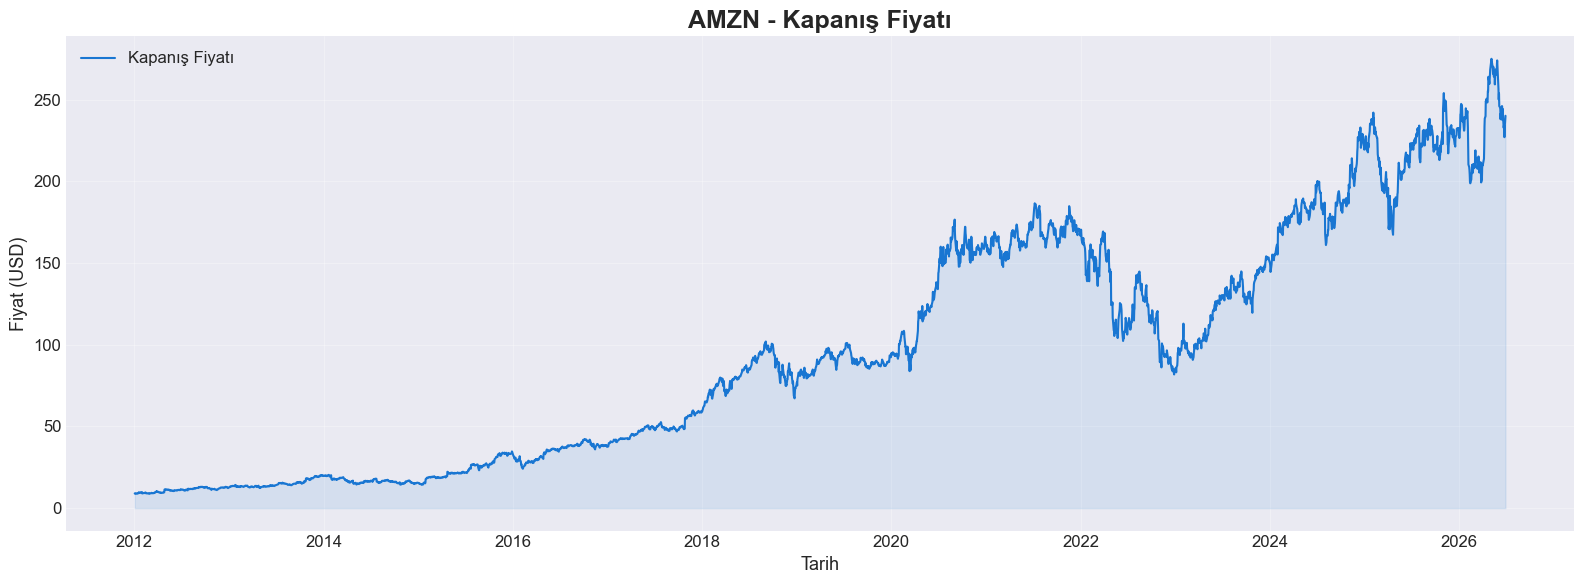

Grafik kaydedildi: results/kapanış_fiyati.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(data.index, data['Close'], color='#1976D2', linewidth=1.5, label='Kapanış Fiyatı')
ax.fill_between(data.index, data['Close'], alpha=0.1, color='#1976D2')

ax.set_title(f'{ticker} - Kapanış Fiyatı', fontsize=18, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=13)
ax.set_ylabel('Fiyat (USD)', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/kapanış_fiyati.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: results/kapanış_fiyati.png")

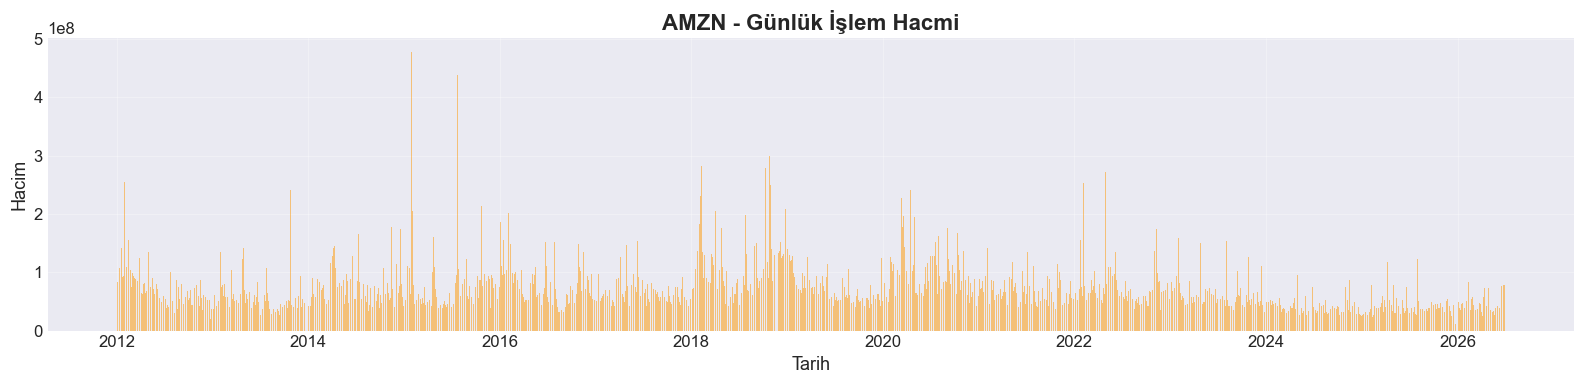

In [10]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.bar(data.index, data['Volume'], color='#FF9800', alpha=0.5, width=1)
ax.set_title(f'{ticker} - Günlük İşlem Hacmi', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=13)
ax.set_ylabel('Hacim', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

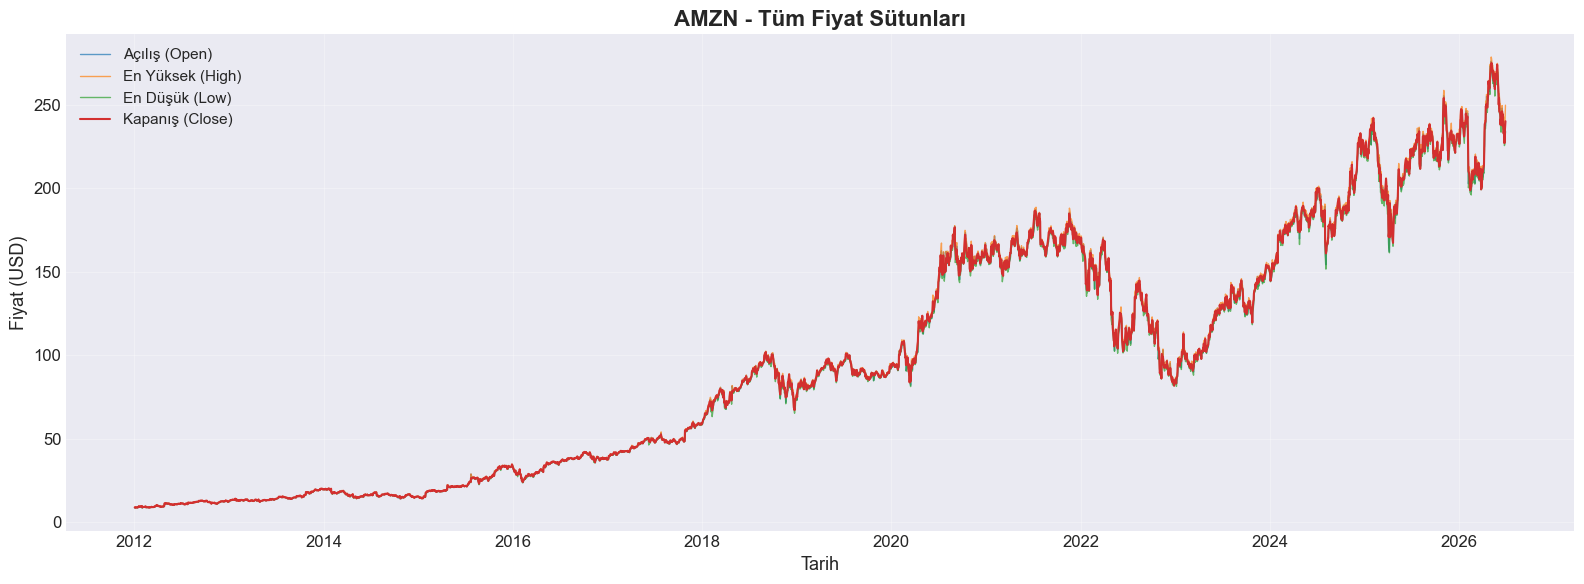

In [11]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(data.index, data['Open'], label='Açılış (Open)', linewidth=1, alpha=0.7)
ax.plot(data.index, data['High'], label='En Yüksek (High)', linewidth=1, alpha=0.7)
ax.plot(data.index, data['Low'], label='En Düşük (Low)', linewidth=1, alpha=0.7)
ax.plot(data.index, data['Close'], label='Kapanış (Close)', linewidth=1.5, color='#D32F2F')

ax.set_title(f'{ticker} - Tüm Fiyat Sütunları', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=13)
ax.set_ylabel('Fiyat (USD)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

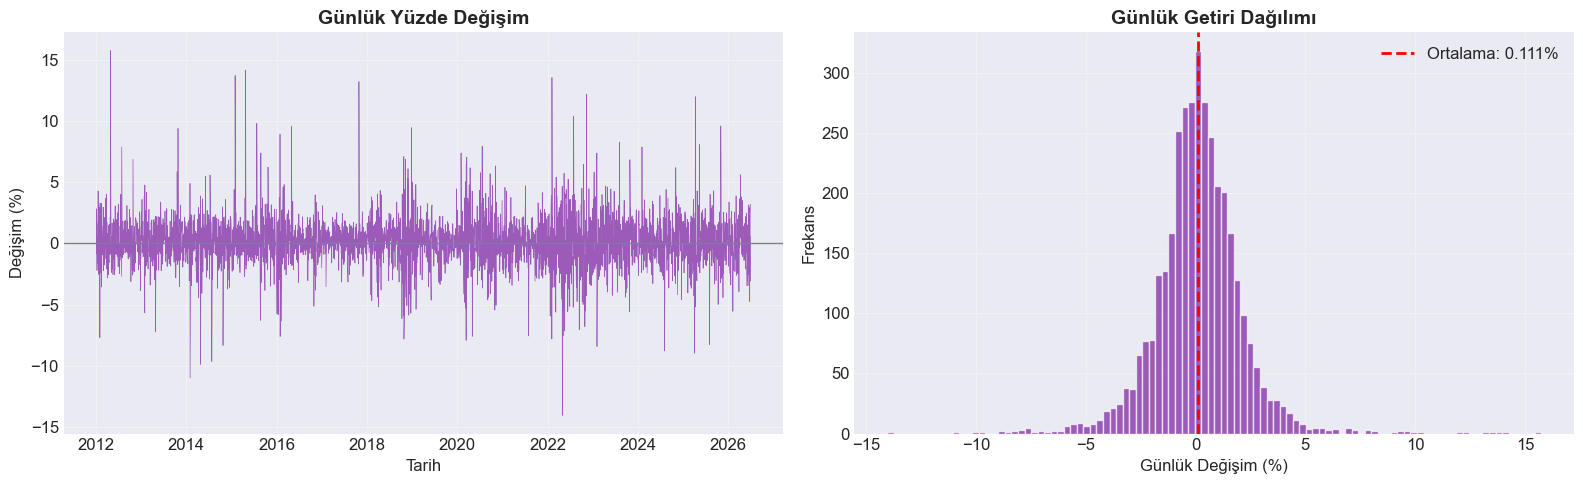

Ortalama günlük değişim : 0.1111%
Standart sapma          : 2.0398%
En büyük günlük düşüş   : -14.05%
En büyük günlük yükseliş: 15.75%


In [12]:
# Günlük yüzde değişim hesapla
daily_returns = data['Close'].pct_change().dropna() * 100  # yüzde olarak

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: Zaman serisi olarak
axes[0].plot(daily_returns.index, daily_returns, color='#7B1FA2', linewidth=0.5, alpha=0.7)
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=1)
axes[0].set_title('Günlük Yüzde Değişim', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tarih')
axes[0].set_ylabel('Değişim (%)')
axes[0].grid(True, alpha=0.3)

# Sağ: Histogram (dağılım)
axes[1].hist(daily_returns, bins=100, color='#7B1FA2', alpha=0.7, edgecolor='white')
axes[1].axvline(x=daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Ortalama: {daily_returns.mean():.3f}%')
axes[1].set_title('Günlük Getiri Dağılımı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Günlük Değişim (%)')
axes[1].set_ylabel('Frekans')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/gunluk_degisim.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ortalama günlük değişim : {daily_returns.mean():.4f}%")
print(f"Standart sapma          : {daily_returns.std():.4f}%")
print(f"En büyük günlük düşüş   : {daily_returns.min():.2f}%")
print(f"En büyük günlük yükseliş: {daily_returns.max():.2f}%")

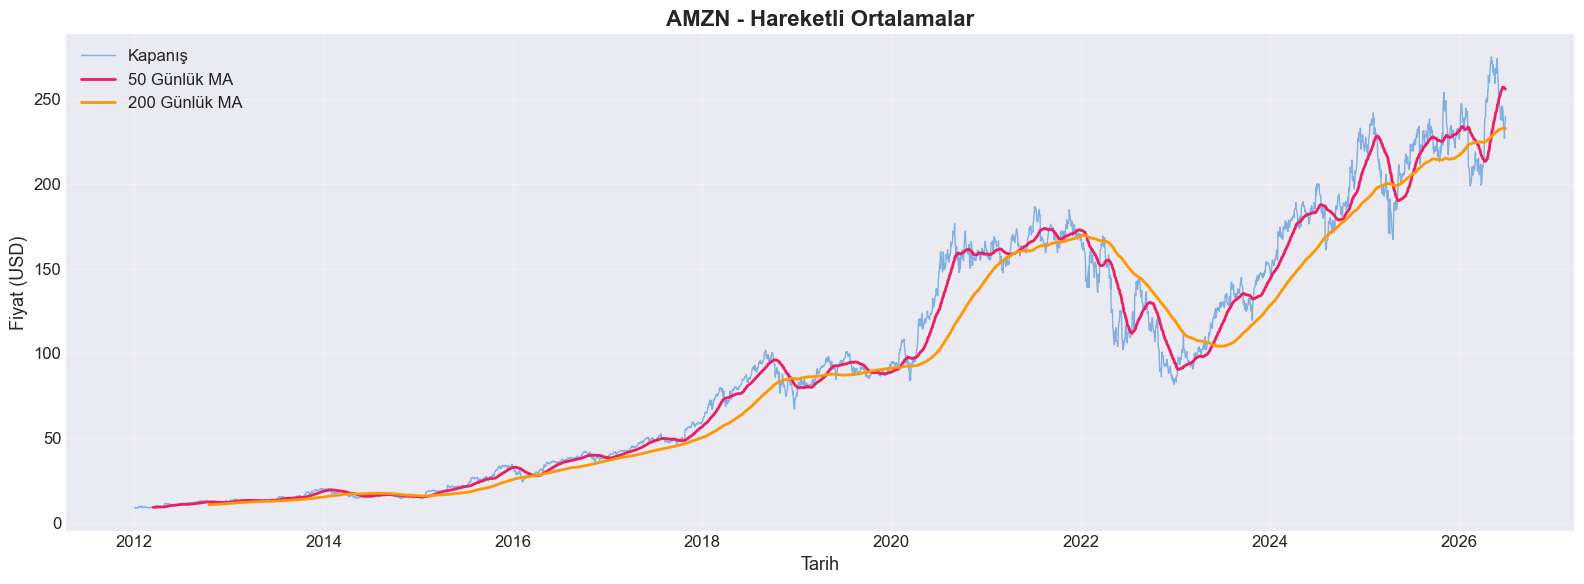

In [13]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(data.index, data['Close'], color='#1976D2', linewidth=1, alpha=0.5, label='Kapanış')
ax.plot(data.index, data['Close'].rolling(50).mean(), color='#E91E63', linewidth=2, label='50 Günlük MA')
ax.plot(data.index, data['Close'].rolling(200).mean(), color='#FF9800', linewidth=2, label='200 Günlük MA')

ax.set_title(f'{ticker} - Hareketli Ortalamalar', fontsize=16, fontweight='bold')
ax.set_xlabel('Tarih', fontsize=13)
ax.set_ylabel('Fiyat (USD)', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/hareketli_ortalamalar.png', dpi=150, bbox_inches='tight')
plt.show()